In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#csv load
df=pd.read_csv("city_day.csv")
print(df)

                City        Date  PM2.5   PM10     NO    NO2    NOx    NH3  \
0          Ahmedabad  2015-01-01    NaN    NaN   0.92  18.22  17.15    NaN   
1          Ahmedabad  2015-01-02    NaN    NaN   0.97  15.69  16.46    NaN   
2          Ahmedabad  2015-01-03    NaN    NaN  17.40  19.30  29.70    NaN   
3          Ahmedabad  2015-01-04    NaN    NaN   1.70  18.48  17.97    NaN   
4          Ahmedabad  2015-01-05    NaN    NaN  22.10  21.42  37.76    NaN   
...              ...         ...    ...    ...    ...    ...    ...    ...   
29526  Visakhapatnam  2020-06-27  15.02  50.94   7.68  25.06  19.54  12.47   
29527  Visakhapatnam  2020-06-28  24.38  74.09   3.42  26.06  16.53  11.99   
29528  Visakhapatnam  2020-06-29  22.91  65.73   3.45  29.53  18.33  10.71   
29529  Visakhapatnam  2020-06-30  16.64  49.97   4.05  29.26  18.80  10.03   
29530  Visakhapatnam  2020-07-01  15.00  66.00   0.40  26.85  14.05   5.20   

          CO    SO2      O3  Benzene  Toluene  Xylene   AQI    

In [6]:
#understand data structure
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [14]:
df.isnull().sum()

City              0
Date              0
PM2.5             0
PM10              0
NO             3582
NO2               0
NOx            4185
NH3           10328
CO                0
SO2               0
O3                0
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [13]:
# apde check karyu ketli value missing che 
missing_data=df.isnull()
missing_data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True
1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True


In [ ]:
for column in missing_data.columns.values.tolist():
    # Prints the name of the current column being processed.
    print(column) 
    # For the current column, it calculates and prints the number of times each unique value (e.g., True or False) appears.
    print (missing_data[column].value_counts())
    print("") 

City
City
False    29531
Name: count, dtype: int64

Date
Date
False    29531
Name: count, dtype: int64

PM2.5
PM2.5
False    24933
True      4598
Name: count, dtype: int64

PM10
PM10
False    18391
True     11140
Name: count, dtype: int64

NO
NO
False    25949
True      3582
Name: count, dtype: int64

NO2
NO2
False    25946
True      3585
Name: count, dtype: int64

NOx
NOx
False    25346
True      4185
Name: count, dtype: int64

NH3
NH3
False    19203
True     10328
Name: count, dtype: int64

CO
CO
False    27472
True      2059
Name: count, dtype: int64

SO2
SO2
False    25677
True      3854
Name: count, dtype: int64

O3
O3
False    25509
True      4022
Name: count, dtype: int64

Benzene
Benzene
False    23908
True      5623
Name: count, dtype: int64

Toluene
Toluene
False    21490
True      8041
Name: count, dtype: int64

Xylene
Xylene
True     18109
False    11422
Name: count, dtype: int64

AQI
AQI
False    24850
True      4681
Name: count, dtype: int64

AQI_Bucket
AQI_Bucket
False  

In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
for col in pollutants:
    df[col].fillna(df[col].mean())


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
# Convert date column to datetime.Required for time-series analysis and line plots.

In [15]:
df[pollutants].describe()

,PM2.5,PM10,NO2,SO2,CO,O3
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,67.450578,118.127103,28.560659,14.531977,2.248598,34.491430
std,59.414476,71.500953,22.941051,16.909088,6.715753,20.163443
min,0.040000,0.010000,0.010000,0.010000,0.000000,0.010000
25%,32.150000,79.315000,12.980000,6.090000,0.540000,20.740000
50%,58.030000,118.127103,25.240000,10.480000,0.950000,34.491430
75%,72.450000,118.127103,34.665000,14.531977,1.710000,42.730000
max,949.990000,1000.000000,362.210000,193.860000,175.810000,257.730000


In [ ]:
df.groupby('City')[pollutants].mean()
# calculates the average (mean) value of specific pollutant columns, grouped by city

,PM2.5,PM10,NO2,SO2,CO,O3
City,,,,,,
Ahmedabad,67.728234,117.409318,49.805675,42.281148,16.147420,37.565152
Aizawl,18.020630,24.191567,0.388496,7.378053,0.283628,6.159494
Amaravati,39.614400,78.777456,22.545012,14.277044,0.793211,37.905530
Amritsar,56.724459,115.353495,18.883865,9.027176,0.656948,23.553460
Bengaluru,38.118529,89.494244,27.996732,5.545939,1.840878,32.984443
Bhopal,50.601160,119.287038,31.258602,13.110511,0.923001,59.061290
Brajrajnagar,64.726798,123.094114,19.524152,10.760311,1.870288,20.471759
Chandigarh,42.428943,85.656546,11.834088,10.159375,0.631349,20.047204
Chennai,51.417112,109.815308,17.067334,7.996432,1.082048,32.493758


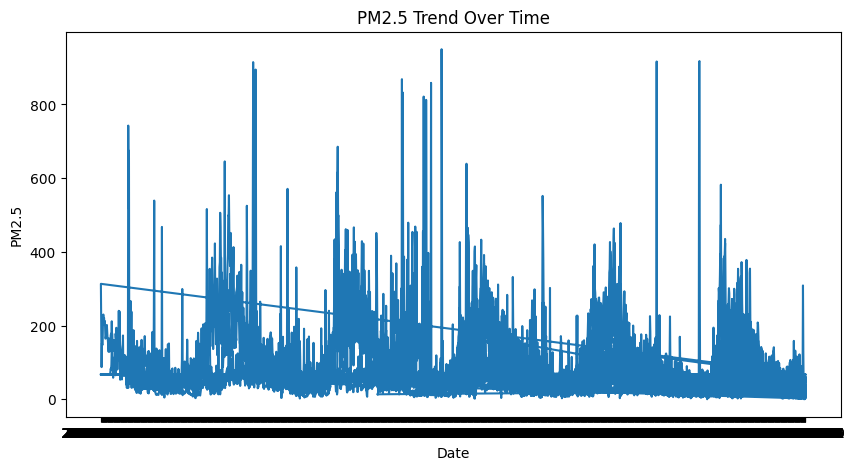

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['PM2.5'])
plt.title("PM2.5 Trend Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.show()
# Time-series (trend over time)
# Line plot for PM2.5 over time.

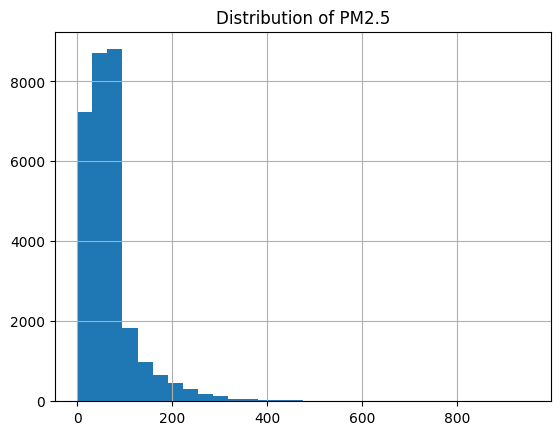

In [ ]:
df['PM2.5'].hist(bins=30)
plt.title("Distribution of PM2.5")
plt.show()
# Distribution analysis (Histogram)
# Check how pollution values are distributed.

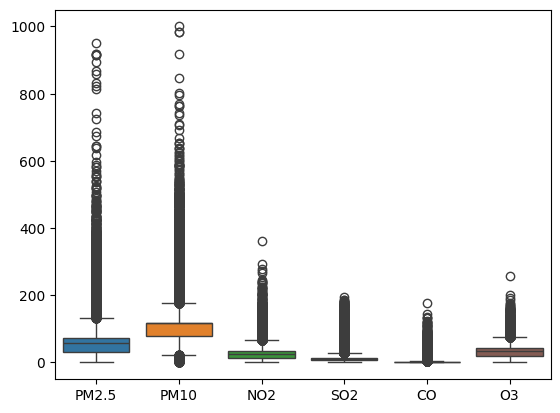

In [ ]:
sns.boxplot(data=df[pollutants])
plt.show()
# Outlier detection (Boxplot)
# Which pollutant has many outliers.

In [ ]:
# Correlation analysis
corr = df[pollutants].corr()
corr


,PM2.5,PM10,NO2,SO2,CO,O3
PM2.5,1.000000,0.558079,0.344341,0.119512,0.086663,0.155330
PM10,0.558079,1.000000,0.359165,0.176188,0.047517,0.203595
NO2,0.344341,0.359165,1.000000,0.382758,0.353237,0.285448
SO2,0.119512,0.176188,0.382758,1.000000,0.472583,0.156610
CO,0.086663,0.047517,0.353237,0.472583,1.000000,0.039787
O3,0.155330,0.203595,0.285448,0.156610,0.039787,1.000000


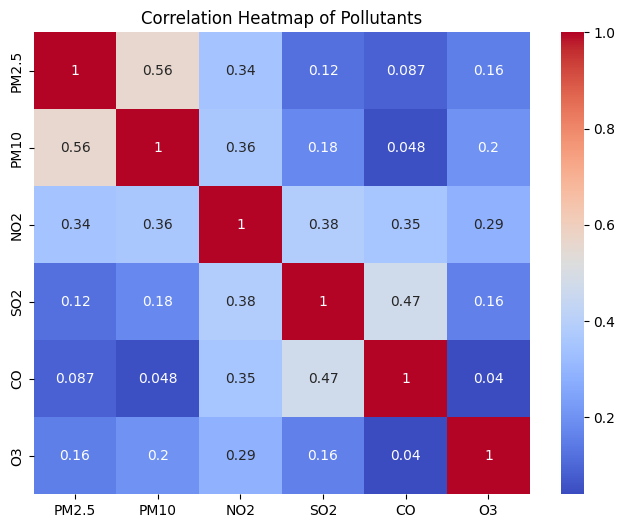

In [ ]:

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Pollutants")
plt.show()


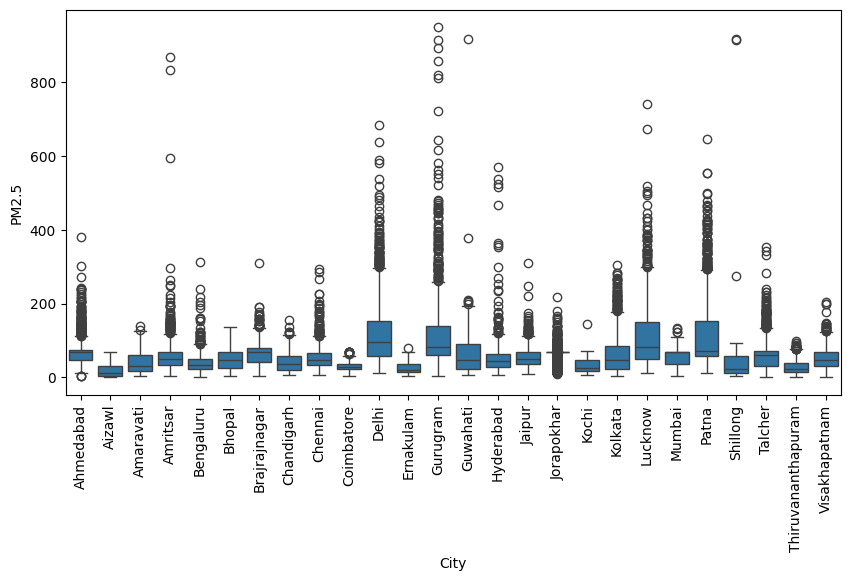

In [ ]:
# City comparison (Boxplot)
plt.figure(figsize=(10,5))
sns.boxplot(x='City', y='PM2.5', data=df)
plt.xticks(rotation=90)
plt.show()